### Práctica

Puedes utilizar este notebook para analisar el dataset propuesto

In [115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display
import seaborn as sns
# split para modelado
from sklearn.model_selection import train_test_split
# Scaled | Escalado
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# Encoding | Codificación
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
# To save models
import json
import pickle
# Feature Selection
from sklearn.feature_selection import f_classif, SelectKBest



## levanto el csv a un df

In [72]:
df = pd.read_csv('../data/raw/p4ds_cadenas_unificadas_2025.csv')

In [73]:
df.head()

,Periodo,Grupo,Producto,Super,Precio
0,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Devoto,"80,00"
1,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Devoto Express,"99,00"
2,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Disco,"99,00"
3,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Ta - Ta,"95,00"
4,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Tienda Inglesa,"97,00"


### Analisis descriptivo

In [74]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Tamaño y columnas
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
df.columns

# Tipos de datos y nulos
df.info()


# Resumen estadístico
df.describe(include='all')

# Valores nulos
nulos = df.isna().sum().sort_values(ascending=False)
nulos[nulos > 0]

# Duplicados
print("Filas duplicadas:", df.duplicated().sum())

df.duplicated()



Filas: 26834
Columnas: 5
<class 'pandas.DataFrame'>
RangeIndex: 26834 entries, 0 to 26833
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Periodo   26834 non-null  str  
 1   Grupo     26671 non-null  str  
 2   Producto  26812 non-null  str  
 3   Super     24237 non-null  str  
 4   Precio    26401 non-null  str  
dtypes: str(5)
memory usage: 3.0 MB
Filas duplicadas: 1625


0        False
1        False
2        False
3        False
4        False
         ...  
26829    False
26830    False
26831    False
26832    False
26833    False
Length: 26834, dtype: bool

In [75]:
# Cantidad de valores únicos por columna
df.nunique().sort_values(ascending=False)

df[df.isnull().any(axis=1)]

df.isnull().any(axis=1).sum()

df.isnull().sum()

df_nulos = df[df.isnull().any(axis=1)]
df_nulos

,Periodo,Grupo,Producto,Super,Precio
1831,Abr25,NaN,Establecimientos Relevados,Devoto,"23,00"
1832,Abr25,NaN,Establecimientos Relevados,Devoto Express,"36,00"
1833,Abr25,NaN,Establecimientos Relevados,Disco,"29,00"
1834,Abr25,NaN,Establecimientos Relevados,El Clon,"16,00"
1835,Abr25,NaN,Establecimientos Relevados,El Dorado,"68,00"
...,...,...,...,...,...
26184,Dic25,Alimentos y bebidas,Harina trigo común 0000 Primor Paquete 1 kg.,Macro,NaN
26461,Dic25,Establecimientos Relevados,NaN,Disco,"300,00"
26516,Ene25,NaN,Establecimientos Relevados,Red Market,"60,00"
26624,Dic25,Establecimientos Relevados,NaN,Red Expres,"590,00"


In [76]:
df = df.dropna()

df.isnull().sum()


Periodo     0
Grupo       0
Producto    0
Super       0
Precio      0
dtype: int64

In [77]:
df.info()

df

<class 'pandas.DataFrame'>
Index: 23643 entries, 0 to 26833
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Periodo   23643 non-null  str  
 1   Grupo     23643 non-null  str  
 2   Producto  23643 non-null  str  
 3   Super     23643 non-null  str  
 4   Precio    23643 non-null  str  
dtypes: str(5)
memory usage: 2.9 MB


,Periodo,Grupo,Producto,Super,Precio
0,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Devoto,"80,00"
1,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Devoto Express,"99,00"
2,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Disco,"99,00"
3,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Ta - Ta,"95,00"
4,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Tienda Inglesa,"97,00"
...,...,...,...,...,...
26829,Dic25,Cuidado personal,"Afeitadora Xtreme3 Piel Delicada X1, 1 unidad",Devoto Express,"1010,00"
26830,Mar25,Cuidado personal,"Perfume Delice Candy, 50 ml.",Farmashop,"6210,00"
26831,Feb25,Cuidado personal,"Toallitas Femeninas Ladysoft Basica, 16 us.",Tienda Inglesa,"1780,00"
26832,Dic25,Frutas y verduras,"Papa Blanca, 1 kg.",Disco,"1090,00"


### Observaciones:

Una vez revisada la información del dataframe, se pueden extraer las siguientes conclusiones:

- El dataset contiene un total de **26.834 filas** y **5 columnas**: `Periodo`, `Grupo`, `Producto`, `Super` y `Precio`.
- La variable `Periodo` no tiene valores nulos, por lo que todas las filas cuentan con un período asociado.
- La variable con mayor cantidad de valores nulos es `Super`, con **2.597 valores faltantes**.
- La variable `Precio` tiene **433 valores nulos**, por lo que hay productos/registros sin precio informado.
- La variable `Grupo` tiene **163 valores nulos** y `Producto` tiene **22 valores nulos**.
- En total, existen **3.191 filas con al menos un valor nulo**.
- Si se eliminan todas las filas con valores nulos usando `df.dropna()`, el dataset queda con **23.643 filas**.
- Todas las columnas aparecen inicialmente como categóricas/texto (`object` o `str`), incluso `Precio`.
- La columna `Precio` debería transformarse a numérica, ya que actualmente usa coma decimal, por ejemplo `80,00`.
- El dataset contiene información de **12 períodos**, **10 grupos**, **427 productos** y **17 supermercados** distintos.


## Limpieza de datos

### Eliminación de duplicados

In [78]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
26829    False
26830    False
26831    False
26832    False
26833    False
Length: 23643, dtype: bool

In [79]:
df.duplicated().sum()

np.int64(1511)

In [80]:
df = df.drop_duplicates().reset_index(drop=True)

In [81]:
df.duplicated().sum()

np.int64(0)

### Normalizacion de columnas

In [82]:
df["Grupo"].value_counts(dropna=False)
df["Grupo"] = df["Grupo"].str.strip().str.lower()

df["Grupo"] = df["Grupo"].str.strip().str.lower().str.capitalize()

# Verifico
df["Grupo"].value_counts(dropna=False)


Grupo
Alimentos y bebidas    13054
Cuidado personal        6685
Limpieza del hogar      1475
Frutas y verduras        901
Familia                   17
Name: count, dtype: int64

In [83]:
columnas_texto = ["Periodo", "Grupo", "Producto", "Super"]

for col in columnas_texto:
    df[col] = df[col].str.strip()

df["Grupo"] = df["Grupo"].str.strip().str.lower().str.capitalize()
df["Super"] = df["Super"].str.strip().str.title()
df["Producto"] = df["Producto"].str.strip().str.lower()

df["Periodo"] = df["Periodo"].str.strip()
df["Grupo"] = df["Grupo"].str.strip().str.lower().str.capitalize()
df["Producto"] = df["Producto"].str.strip().str.lower()
df["Super"] = df["Super"].str.strip().str.title()

#Verifico
df.nunique()

df["Grupo"].value_counts()
df["Super"].value_counts()

Super
Red Expres        2065
Tienda Inglesa    2052
Red Market        2015
Disco             1799
Devoto            1769
Ta - Ta           1748
El Dorado         1620
Macro             1619
Devoto Express    1476
Micro Macro       1442
El Clon           1080
Farmashop          763
Farmaglobal        724
Frog               717
Kinko              486
San Roque          409
Pigalle            348
Name: count, dtype: int64

In [87]:
# Limpieza básica del precio
df['Precio'] = (
    df['Precio']
    .astype(str)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float)
)


## Limpieza de datos: Eliminación de información irrelevante

In [99]:
df[df["Grupo"] == "Familia"].shape

df = df[df["Grupo"] != "Familia"].reset_index(drop=True)

df["Grupo"].value_counts()

Grupo
Alimentos y bebidas    12397
Cuidado personal        5181
Limpieza del hogar      1440
Frutas y verduras        886
Name: count, dtype: int64

### Conclusión
#### No tenemos datos irrelevantes a eliminar, todos aportan valor al analisis, lo que si necesitamos quitar a "Familia" de Grupo, ya que no era una categoría correcta.

### Paso 4: Análisis de variables

#### Análisis de Variables Univariante Categóricas

Una **variable categórica** es un tipo de variable que puede tomar uno de un número limitado de categorías o grupos. Estos grupos suelen ser nominales, es decir, representan nombres o clases sin un orden numérico natural.

En este dataset, las variables categóricas permiten identificar dimensiones como el período relevado, el grupo de producto, el producto específico y el supermercado donde se registró el precio.

Antes de comenzar a graficar, debemos identificar cuáles son categóricas. En este caso, las variables categóricas son: `Periodo`, `Grupo`, `Producto` y `Super`.

La variable `Precio` no se considera categórica para el análisis, ya que representa un valor monetario y debería analizarse como variable numérica una vez convertida correctamente.

In [100]:
df.dtypes

variables_categoricas = ["Periodo", "Grupo", "Producto", "Super"]

df[variables_categoricas].nunique()


Periodo      12
Grupo         4
Producto    404
Super        17
dtype: int64

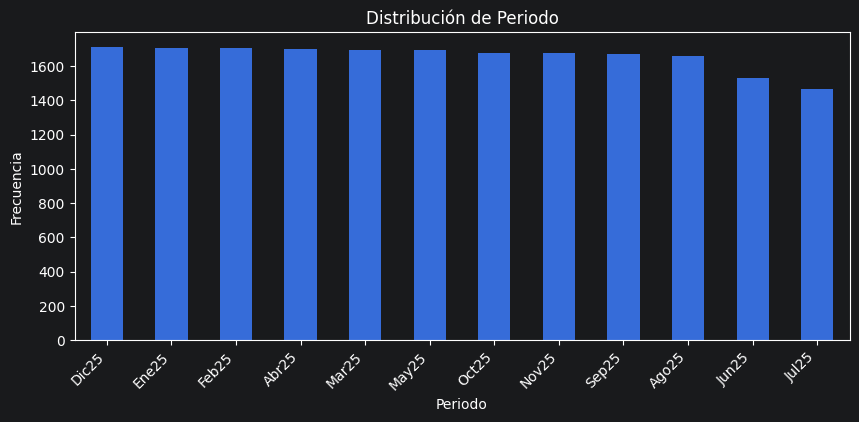

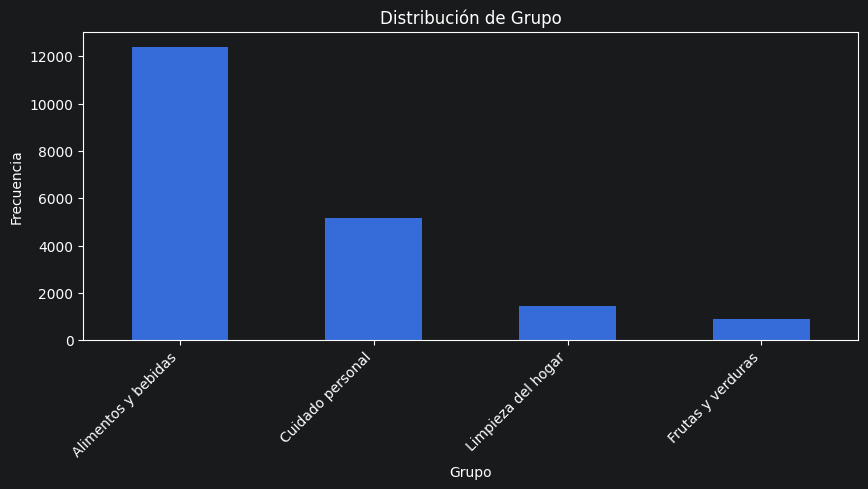

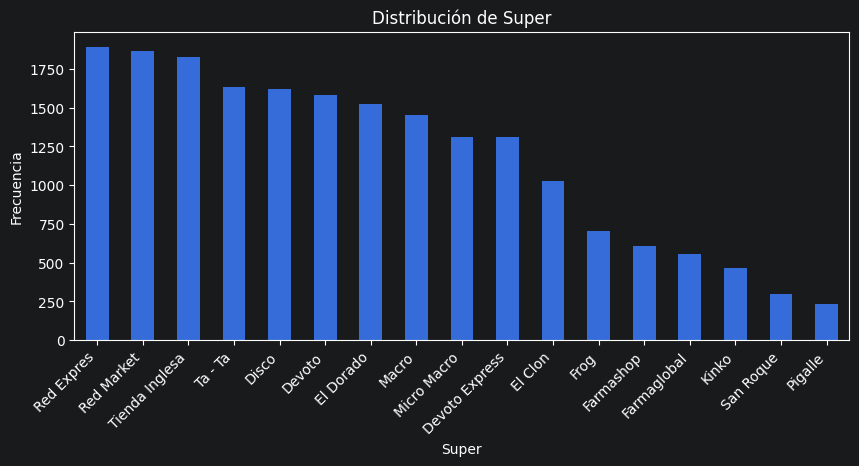

In [101]:
variables_categoricas = ["Periodo", "Grupo", "Super"]

for col in variables_categoricas:
    plt.figure(figsize=(10, 4))
    df[col].value_counts().plot(kind="bar")
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.xticks(rotation=45, ha="right")
    plt.show()

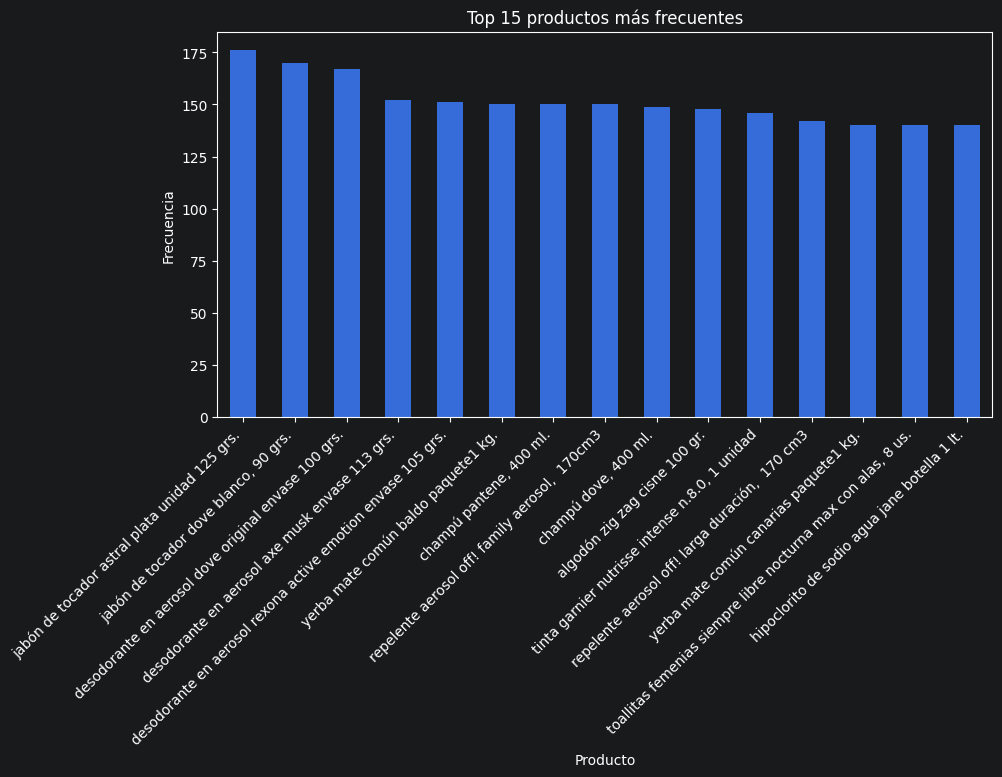

In [102]:
plt.figure(figsize=(10, 5))
df["Producto"].value_counts().head(15).plot(kind="bar")
plt.title("Top 15 productos más frecuentes")
plt.xlabel("Producto")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45, ha="right")
plt.show()

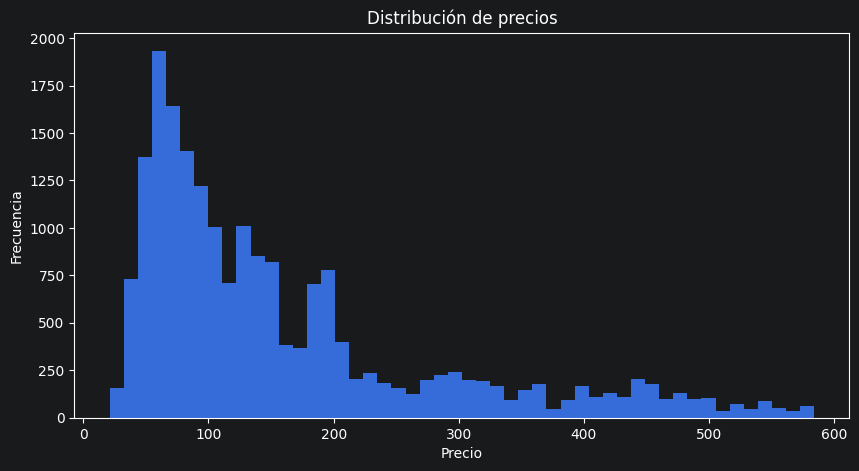

<Figure size 1000x500 with 0 Axes>

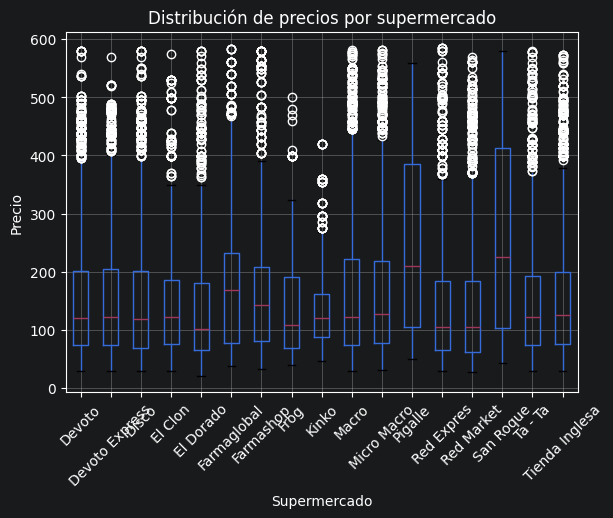

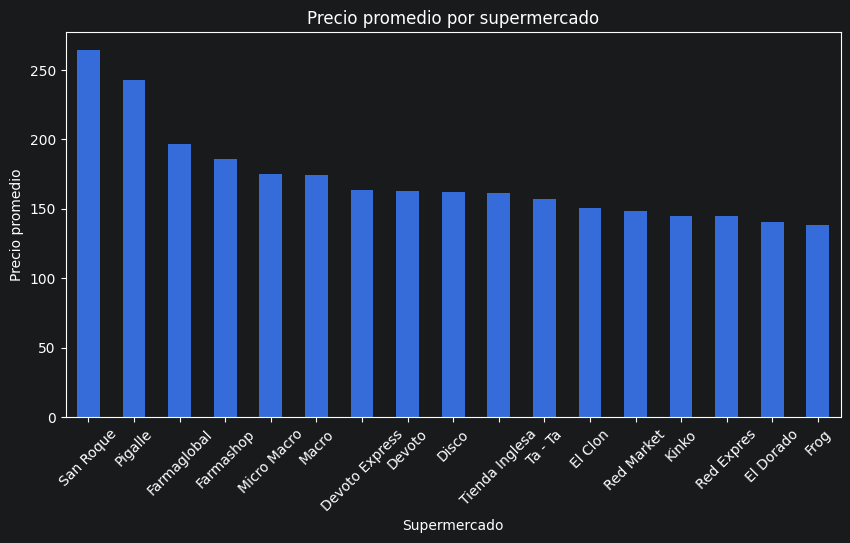

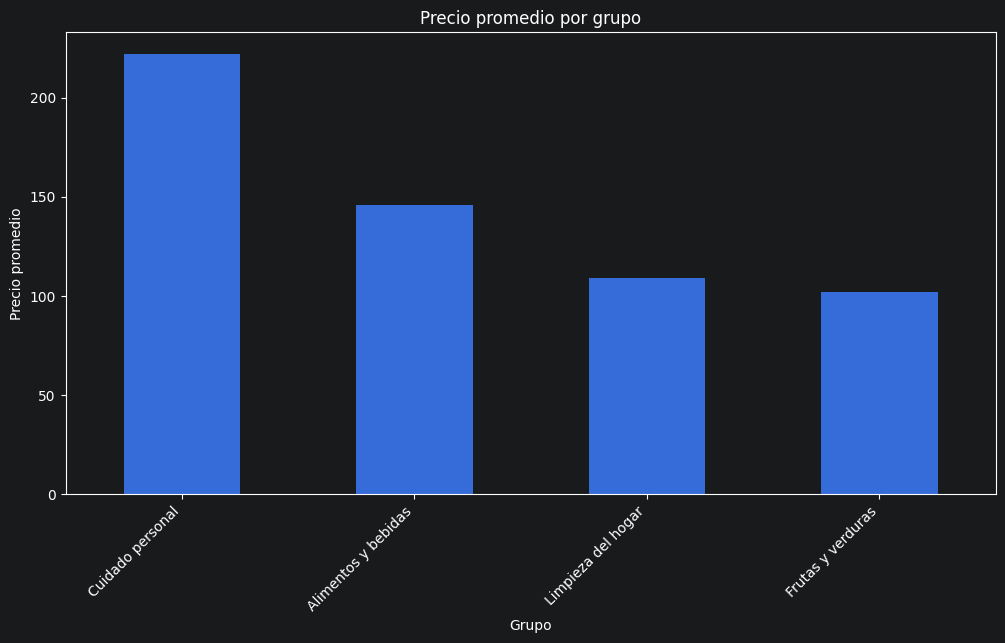

Super,Devoto,Devoto Express,Disco,El Clon,El Dorado,Farmaglobal,Farmashop,Frog,Kinko,Macro,Micro Macro,Pigalle,Red Expres,Red Market,San Roque,Ta - Ta,Tienda Inglesa,diferencia_max_min
Producto,,,,,,,,,,,,,,,,,,
shampoo comun fructis (envase 350 ml.),261.00,NaN,249.00,NaN,325.00,406.00,360.00,NaN,NaN,330.90,NaN,360.00,333.50,183.00,360.00,367.50,360.00,223.00
champú fructis envase 350 ml.,284.40,294.80,284.40,279.00,323.20,404.92,358.33,NaN,NaN,311.40,308.51,340.50,291.10,184.60,359.00,353.90,354.70,220.32
"repelente spray off! family, 177 cm3",512.00,341.00,512.00,525.00,NaN,NaN,554.00,NaN,NaN,474.41,511.60,509.00,558.20,NaN,554.00,545.38,541.20,217.20
tinta comun excellence (1 unidad),NaN,NaN,549.00,NaN,549.00,NaN,NaN,NaN,NaN,444.70,444.70,NaN,NaN,362.50,NaN,NaN,559.30,196.80
repelente de mosquitos aerosol off! (170 cm3),429.00,NaN,421.00,289.00,353.00,483.90,465.50,NaN,NaN,401.70,418.75,452.00,383.00,405.50,456.00,349.00,376.00,194.90
arroz calidad media vidarroz (bolsa 1 kg.),211.33,NaN,40.00,NaN,21.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.00,NaN,190.33
jabon de tocador en barra rexona (unidad 125 grs.),49.00,NaN,49.00,45.00,46.45,68.00,NaN,NaN,NaN,65.10,NaN,NaN,224.00,49.00,NaN,75.00,56.90,179.00
talco comun johnson & johnson (200 grs.),439.00,NaN,439.00,NaN,439.00,520.10,390.00,399.00,NaN,417.80,NaN,435.00,347.00,372.50,477.00,418.00,485.50,173.10
nalga sin hueso sin marca (1 kg.),385.00,NaN,374.00,NaN,NaN,NaN,NaN,NaN,NaN,547.00,547.00,NaN,NaN,472.00,NaN,389.00,NaN,173.00


In [103]:
# Frecuencia por supermercado
df['Super'].value_counts()

# Frecuencia por grupo
df['Grupo'].value_counts()

# Frecuencia por periodo
df['Periodo'].value_counts().sort_index()

# Precio promedio por supermercado
df.groupby('Super')['Precio'].agg(['count', 'mean', 'median', 'min', 'max']).sort_values('mean', ascending=False)

# Precio promedio por grupo
df.groupby('Grupo')['Precio'].agg(['count', 'mean', 'median', 'min', 'max']).sort_values('mean', ascending=False)

# Productos más caros en promedio
df.groupby('Producto')['Precio'].mean().sort_values(ascending=False).head(20)

# Productos más baratos en promedio
df.groupby('Producto')['Precio'].mean().sort_values().head(20)

# Histograma de precios
plt.figure(figsize=(10, 5))
plt.hist(df['Precio'], bins=50)
plt.title('Distribución de precios')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.show()

# Boxplot de precios por supermercado
plt.figure(figsize=(10, 5))
df.boxplot(column='Precio', by='Super', rot=45)
plt.title('Distribución de precios por supermercado')
plt.suptitle('')
plt.xlabel('Supermercado')
plt.ylabel('Precio')
plt.show()

# Precio promedio por supermercado
precio_super = df.groupby('Super')['Precio'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
precio_super.plot(kind='bar')
plt.title('Precio promedio por supermercado')
plt.xlabel('Supermercado')
plt.ylabel('Precio promedio')
plt.xticks(rotation=45)
plt.show()

# Precio promedio por grupo
precio_grupo = df.groupby('Grupo')['Precio'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
precio_grupo.plot(kind='bar')
plt.title('Precio promedio por grupo')
plt.xlabel('Grupo')
plt.ylabel('Precio promedio')
plt.xticks(rotation=45, ha='right')
plt.show()

# Comparación supermercado vs grupo
tabla_super_grupo = pd.pivot_table(
    df,
    values='Precio',
    index='Grupo',
    columns='Super',
    aggfunc='mean'
)

tabla_super_grupo

# Diferencia entre supermercados por producto
comparacion_productos = pd.pivot_table(
    df,
    values='Precio',
    index='Producto',
    columns='Super',
    aggfunc='mean'
)

comparacion_productos['diferencia_max_min'] = comparacion_productos.max(axis=1) - comparacion_productos.min(axis=1)

comparacion_productos.sort_values('diferencia_max_min', ascending=False).head(20)

#### Observaciones

A partir de los gráficos de las variables categóricas, se pueden extraer las siguientes conclusiones:

- **Periodo**: El dataset contiene registros para los 12 meses de 2025. La distribución es bastante pareja entre meses, aunque `Dic25`, `Feb25`, `Ene25` y `Abr25` son los períodos con mayor cantidad de registros. `Jul25` es el período con menor cantidad.
- **Grupo**: La categoría con mayor presencia es `Alimentos y bebidas`, con una diferencia importante frente al resto. Le siguen `Cuidado personal`, `Limpieza del hogar` y `Frutas y verduras`.
- **Grupo**: Antes de normalizar los textos, algunas categorías aparecían duplicadas por diferencias de mayúsculas y minúsculas, por ejemplo `Alimentos y bebidas` y `alimentos y bebidas`. Esto fue corregido al estandarizar el texto.
- **Super**: Existen registros para varios supermercados. Los que tienen mayor cantidad de observaciones son `Red Expres`, `Tienda Inglesa`, `Red Market`, `Disco`, `Devoto` y `Ta - Ta`.
- **Super**: También se observa una cantidad importante de registros sin supermercado informado, por lo que esta variable tenía valores nulos relevantes.
- **Producto**: Es la variable categórica con mayor variedad de valores. Esto es esperable, ya que el dataset contiene muchos productos distintos.
- **Producto**: Debido a la gran cantidad de productos, no conviene analizar todos en un único gráfico de barras. Es más claro observar solo los productos más frecuentes, por ejemplo el top 10 o top 15.

#### Análisis de Variables Univariante Numéricas

Una **variable numérica** es un tipo de variable que puede tomar valores numéricos, como enteros, decimales o valores monetarios. Normalmente se representa utilizando un histograma, para observar su distribución, y un gráfico de caja o boxplot, para identificar valores atípicos.

En este dataset, la principal variable numérica es `Precio`, ya que representa el valor monetario registrado para cada producto en cada supermercado y período.

Sin embargo, antes de graficarla es necesario convertirla a formato numérico, porque originalmente aparece como texto y utiliza coma decimal, por ejemplo `80,00`.

Por lo tanto, la variable numérica a analizar será: `Precio`.

In [104]:
df["Precio"].describe()



count   19,904.00
mean       161.12
std        124.00
min         21.00
25%         73.00
50%        119.00
75%        199.00
max        584.00
Name: Precio, dtype: float64

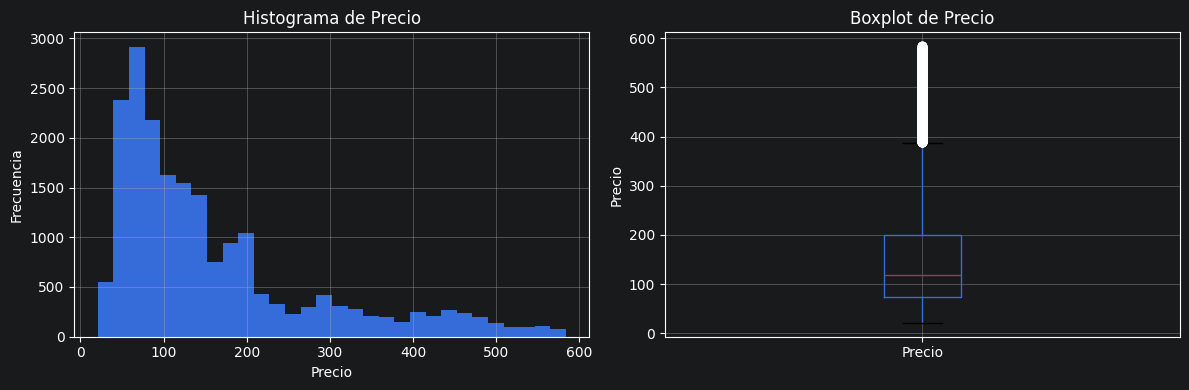

In [105]:
#Grafico

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["Precio"].hist(ax=axes[0], bins=30)
axes[0].set_title("Histograma de Precio")
axes[0].set_xlabel("Precio")
axes[0].set_ylabel("Frecuencia")

df.boxplot(column="Precio", ax=axes[1])
axes[1].set_title("Boxplot de Precio")
axes[1].set_ylabel("Precio")

plt.tight_layout()
plt.show()

In [106]:
# Quito outliers usando el metodo del rango intercuartílico (`IQR`):

Q1 = df["Precio"].quantile(0.25)
Q3 = df["Precio"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

df_sin_outliers = df[
    (df["Precio"] >= limite_inferior) &
    (df["Precio"] <= limite_superior)
].copy()

df_sin_outliers.shape

df.shape[0] - df_sin_outliers.shape[0]


1773

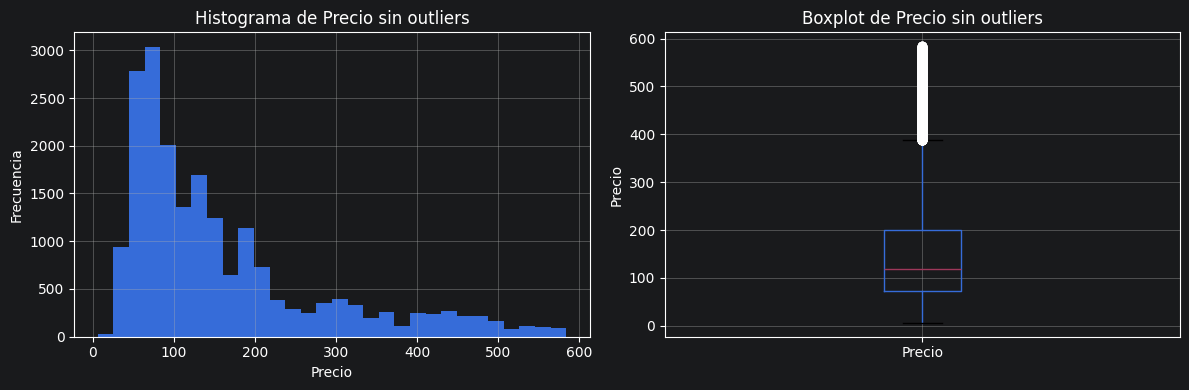

In [92]:
#grafico nuevamente
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_sin_outliers["Precio"].hist(ax=axes[0], bins=30)
axes[0].set_title("Histograma de Precio sin outliers")
axes[0].set_xlabel("Precio")
axes[0].set_ylabel("Frecuencia")

df_sin_outliers.boxplot(column="Precio", ax=axes[1])
axes[1].set_title("Boxplot de Precio sin outliers")
axes[1].set_ylabel("Precio")

plt.tight_layout()
plt.show()

In [93]:
df = df_sin_outliers.reset_index(drop=True)

df_outliers = df[
    (df["Precio"] < limite_inferior) |
    (df["Precio"] > limite_superior)
]

df_outliers.sort_values("Precio", ascending=False).head(20)

,Periodo,Grupo,Producto,Super,Precio


#### Observaciones:

- La combinación del histograma y el boxplot permite analizar la distribución de la variable `Precio` y detectar posibles valores atípicos.
- La variable `Precio` presenta una distribución claramente asimétrica hacia la derecha, ya que la mayoría de los precios se concentran en valores bajos y medios, mientras que existen algunos precios extremadamente altos.
- La mediana del precio es **129**, mientras que la media es aproximadamente **238,65**. Esto indica que los valores altos elevan el promedio.
- El valor mínimo registrado es **6**, mientras que el valor máximo llega a **25.800**, lo cual confirma la presencia de valores atípicos.
- Según el criterio del rango intercuartílico (`IQR`), se consideran outliers los precios superiores a aproximadamente **510**.
- Se identifican alrededor de **2.471 registros atípicos** en la variable `Precio`.
- Estos outliers pueden corresponder a productos efectivamente más caros, errores de carga o productos de categorías muy distintas, por lo que conviene revisarlos antes de eliminarlos definitivamente.
- Para mejorar la visualización general de la distribución, puede trabajarse con un dataframe sin outliers, especialmente si el objetivo es analizar precios típicos.

In [94]:
#El límite inferior da negativo, los outliers relevantes son los precios altos:
df_outliers = df[df["Precio"] > limite_superior].copy()

#Para ver los más extremos:
df_outliers.sort_values("Precio", ascending=False).head(20)

,Periodo,Grupo,Producto,Super,Precio


In [95]:
#Para analizar por grupo:
df_outliers["Grupo"].value_counts()

#Para analizar por supermercado:
df_outliers["Super"].value_counts()

#Para analizar por producto:
df_outliers["Producto"].value_counts().head(20)

#Comparar estadísticas entre datos normales y outliers:
df["Precio"].describe()

df_outliers["Precio"].describe()


#porcentaje de outliers:

len(df_outliers) / len(df) * 100

# Para una tabla más útil:
df_outliers.groupby("Grupo")["Precio"].agg(
    cantidad="count",
    minimo="min",
    mediana="median",
    promedio="mean",
    maximo="max"
).sort_values("cantidad", ascending=False)


# Por producto
df_outliers.groupby("Producto")["Precio"].agg(
    cantidad="count",
    minimo="min",
    mediana="median",
    promedio="mean",
    maximo="max"
).sort_values("maximo", ascending=False).head(20)


,cantidad,minimo,mediana,promedio,maximo
Producto,,,,,


### Análisis de Variables Multivariante

Tras analizar las variables una a una, es momento de estudiar cómo se relacionan entre sí. En este dataset no existe una variable objetivo o predictora como por ejemplo vimos en `Survived` en el caso del Titanic, por lo que el análisis multivariante se enfoca en entender cómo cambia la variable `Precio` según otras variables del dataset.

El objetivo principal es analizar si los precios varían según el `Grupo`, el `Producto`, el `Super` o el `Periodo`. Esto permite obtener conclusiones más claras sobre el comportamiento de los precios y tomar mejores decisiones sobre limpieza, eliminación de valores nulos u outliers.

Por ejemplo, la variable `Precio` presenta valores atípicos. Antes de eliminarlos, es importante revisar si estos outliers pertenecen a productos específicos, supermercados concretos o determinados grupos. Algunos precios altos podrían no ser errores, sino productos naturalmente más caros, como cremas, protectores solares o pañales.

Del mismo modo, la variable `Super` tiene una cantidad importante de valores nulos. Antes de eliminar esas filas, conviene analizar si esos registros tienen precios, productos o grupos relevantes, ya que podrían aportar información útil al análisis.

Por lo tanto, en este análisis multivariante se estudiará principalmente la relación entre `Precio` y las variables categóricas `Grupo`, `Producto`, `Super` y `Periodo`.

In [107]:
df.groupby("Grupo")["Precio"].describe()
df.groupby("Super")["Precio"].describe()
df.groupby("Periodo")["Precio"].describe()

#Para ver precios promedio por grupo:
df.groupby("Grupo")["Precio"].mean().sort_values(ascending=False)
#Para ver precios promedio por supermercado:
df.groupby("Super")["Precio"].mean().sort_values(ascending=False)
#Para ver precios promedio por mes:
df.groupby("Periodo")["Precio"].mean().sort_values(ascending=False)

#Y para analizar outliers por grupo:
df_outliers.groupby("Grupo")["Precio"].agg(
    cantidad="count",
    minimo="min",
    mediana="median",
    promedio="mean",
    maximo="max"
).sort_values("cantidad", ascending=False)

,cantidad,minimo,mediana,promedio,maximo
Grupo,,,,,


#### Análisis numérico-numérico

Cuando las dos variables que se comparan tienen datos numéricos, se realiza un análisis numérico-numérico. Para comparar dos columnas numéricas se suelen utilizar diagramas de dispersión y análisis de correlaciones.

En este dataset, la única variable numérica relevante es `Precio`, ya que el resto de columnas (`Periodo`, `Grupo`, `Producto` y `Super`) son categóricas.

Por este motivo, no es posible realizar un análisis numérico-numérico tradicional entre dos variables del dataset. Tampoco tendría sentido calcular una matriz de correlación, ya que no existen dos o más variables numéricas para comparar entre sí.

En este caso, el análisis multivariante se enfocará principalmente en comparar la variable numérica `Precio` con variables categóricas como `Grupo`, `Super`, `Producto` y `Periodo`.


In [98]:
#Comprobarlo con código:
df.select_dtypes(include="number").columns

#Ver la correlación disponible:
df.select_dtypes(include="number").corr()
#Devuelve solo Precio, por eso no aporta mucho análisis.

,Precio
Precio,1.00


#### Análisis categórico-categórico

Cuando las dos variables que se comparan son categóricas, se realiza un análisis categórico-categórico. Este tipo de análisis permite observar cómo se distribuyen las categorías de una variable dentro de otra.

En este dataset, las variables categóricas principales son `Periodo`, `Grupo`, `Producto` y `Super`. Por lo tanto, se pueden analizar relaciones como:

- qué grupos de productos aparecen en cada período,
- qué supermercados tienen mayor cantidad de registros por grupo,
- qué productos aparecen con mayor frecuencia en cada supermercado,
- y cómo se distribuyen los grupos de productos entre los supermercados.

Para este análisis se pueden utilizar tablas de frecuencia, tablas cruzadas y gráficos de barras agrupadas o apiladas.

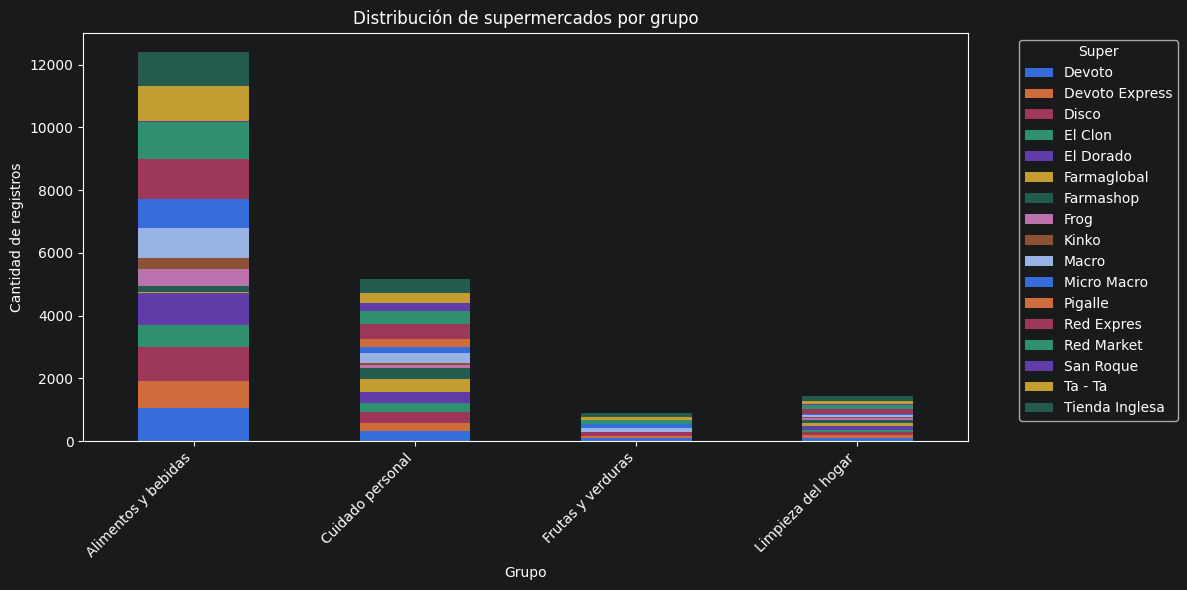

Grupo,Alimentos y bebidas,Cuidado personal,Frutas y verduras,Limpieza del hogar
Periodo,,,,
Abr25,1051,448,78,124
Ago25,1040,428,75,118
Dic25,1060,459,75,120
Ene25,1059,448,76,125
Feb25,1056,450,75,124
Jul25,925,367,64,108
Jun25,951,401,66,114
Mar25,1049,447,74,124
May25,1056,438,75,123


In [109]:
pd.crosstab(df["Grupo"], df["Super"])
# Para verlo con porcentajes por fila:
pd.crosstab(df["Grupo"], df["Super"], normalize="index") * 100
# Ejemplo con gráfico:
tabla_grupo_super = pd.crosstab(df["Grupo"], df["Super"])

tabla_grupo_super.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Distribución de supermercados por grupo")
plt.xlabel("Grupo")
plt.ylabel("Cantidad de registros")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Super", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
# Periodo vs Grupo:
pd.crosstab(df["Periodo"], df["Grupo"])

In [110]:
# Defino categorias
variables_categoricas = ["Periodo", "Grupo", "Producto", "Super"]

# **1. Grupo vs Super**
#Sirve para ver qué supermercados tienen más registros por tipo de producto.

pd.crosstab(df["Grupo"], df["Super"])

pd.crosstab(df["Grupo"], df["Super"], normalize="index") * 100


# **2. Periodo vs Grupo**
# Sirve para ver si todos los grupos aparecen de forma pareja a lo largo de los meses.

pd.crosstab(df["Periodo"], df["Grupo"])

pd.crosstab(df["Periodo"], df["Grupo"], normalize="index") * 100


# **3. Periodo vs Super**
# Sirve para ver si todos los supermercados fueron relevados en todos los períodos.

pd.crosstab(df["Periodo"], df["Super"])

# **4. Super vs Producto**
# Sirve para ver cuántos productos distintos tiene registrado cada supermercado.

df.groupby("Super")["Producto"].nunique().sort_values(ascending=False)

# **5. Grupo vs Producto**
# Sirve para ver cuántos productos distintos hay dentro de cada grupo.

df.groupby("Grupo")["Producto"].nunique().sort_values(ascending=False)

# **6. Producto vs Super**
# Sirve para ver en cuántos supermercados aparece cada producto.

df.groupby("Producto")["Super"].nunique().sort_values(ascending=False).head(20)

# **7. Combinaciones más frecuentes**
# Sirve para detectar qué combinaciones de categorías aparecen más en el dataset.

df.groupby(["Grupo", "Super"]).size().sort_values(ascending=False).head(20)

df.groupby(["Periodo", "Grupo"]).size().sort_values(ascending=False).head(20)

df.groupby(["Producto", "Super"]).size().sort_values(ascending=False).head(20)


Producto                                           Super         
azúcar blanco bella unión paquete 1 kg.            El Dorado         12
azúcar blanco azucarlito paquete 1 kg.             Devoto Express    12
pasta dental kolynos triple acción unidad 90 grs.  Devoto            12
margarina adorita envase 250 grs.                  Macro             12
jabón de tocador astral plata unidad 125 grs.      Ta - Ta           12
hamburguesas carne vacun burgy paquete 3 unidades  El Clon           12
harina de maíz gourmet paquete 450 grs.            Macro             12
azúcar blanco azucarlito paquete 1 kg.             Red Expres        11
                                                   Ta - Ta           11
té negro en saquitos la virginia caja 10 us.       Ta - Ta           11
pasta dental kolynos triple acción unidad 90 grs.  Red Expres        11
arvejas en conserva cololó lata 380 grs.           Micro Macro       11
arroz blanco aruba tipo patna bolsa 1 kg.          Ta - Ta           1

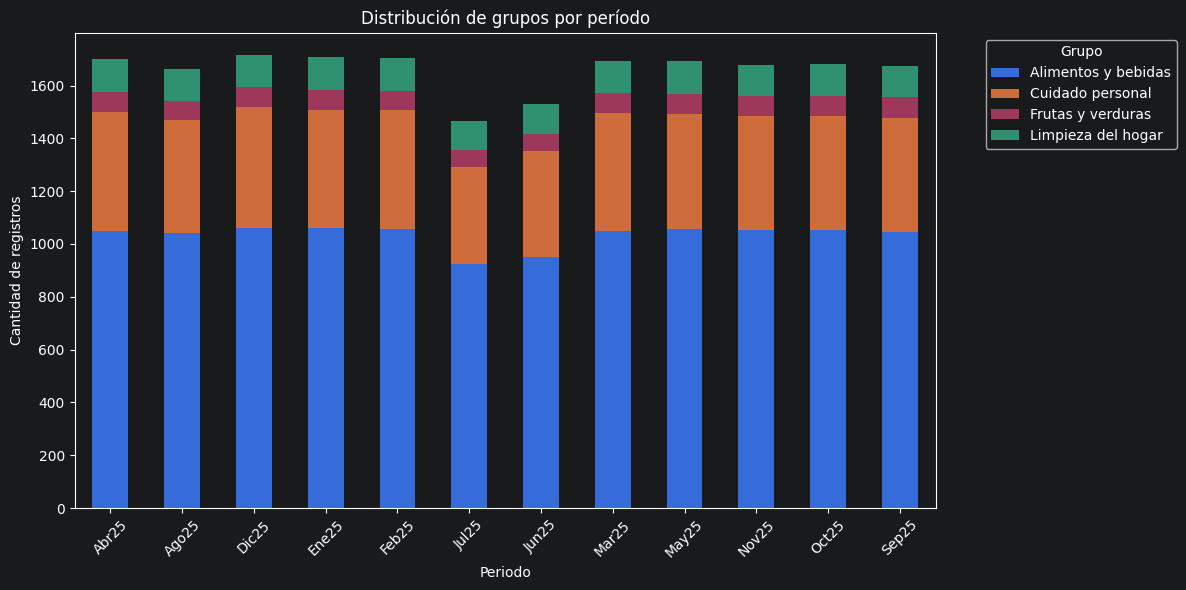

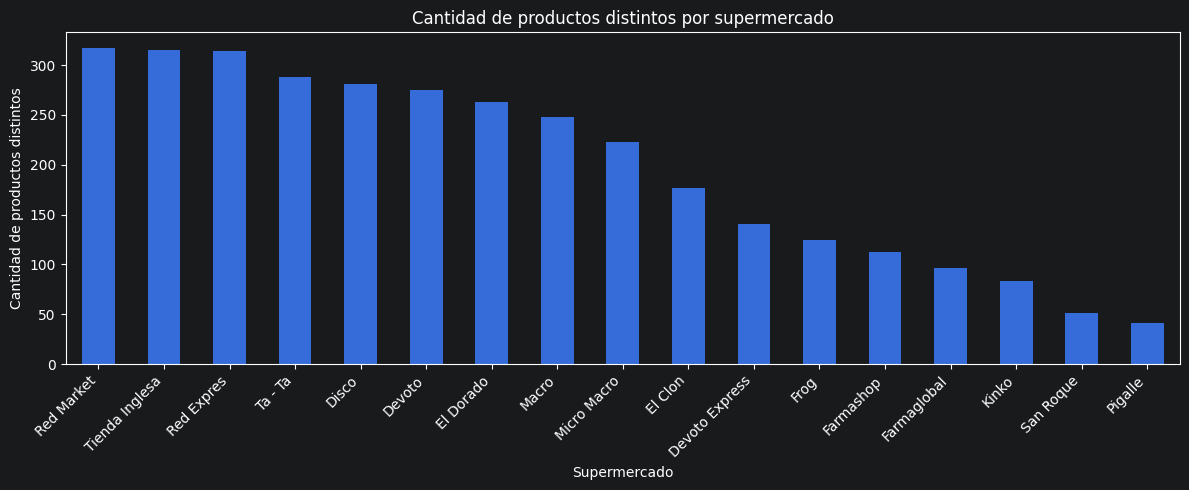

In [111]:
# Para graficar algunos:

tabla = pd.crosstab(df["Periodo"], df["Grupo"])

tabla.plot(kind="bar", stacked=True, figsize=(12, 6))

plt.title("Distribución de grupos por período")
plt.xlabel("Periodo")
plt.ylabel("Cantidad de registros")
plt.xticks(rotation=45)
plt.legend(title="Grupo", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

productos_por_super = df.groupby("Super")["Producto"].nunique().sort_values(ascending=False)

productos_por_super.plot(kind="bar", figsize=(12, 5))

plt.title("Cantidad de productos distintos por supermercado")
plt.xlabel("Supermercado")
plt.ylabel("Cantidad de productos distintos")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [119]:
print("Productos distintos por grupo:")
print(df.groupby("Grupo")["Producto"].nunique().sort_values(ascending=False))

print("Cantidad de registros por grupo:")
print(df["Grupo"].value_counts())

print("Distribución de grupos por período:")
print(pd.crosstab(df["Periodo"], df["Grupo"]))

print("Productos distintos por supermercado:")
print(df.groupby("Super")["Producto"].nunique().sort_values(ascending=False))

print("Productos que aparecen en más supermercados:")
display(df.groupby("Producto")["Super"].nunique().sort_values(ascending=False).head(20))

print("Combinaciones más frecuentes Grupo-Super:")
print(df.groupby(["Grupo", "Super"]).size().sort_values(ascending=False).head(20))

print("Registros sin supermercado informado:")
print(df["Super"].isnull().sum())

Productos distintos por grupo:
Grupo
Alimentos y bebidas    259
Cuidado personal        92
Frutas y verduras       29
Limpieza del hogar      24
Name: Producto, dtype: int64
Cantidad de registros por grupo:
Grupo
Alimentos y bebidas    12397
Cuidado personal        5181
Limpieza del hogar      1440
Frutas y verduras        886
Name: count, dtype: int64
Distribución de grupos por período:
Grupo    Alimentos y bebidas  Cuidado personal  Frutas y verduras  \
Periodo                                                             
Abr25                   1051               448                 78   
Ago25                   1040               428                 75   
Dic25                   1060               459                 75   
Ene25                   1059               448                 76   
Feb25                   1056               450                 75   
Jul25                    925               367                 64   
Jun25                    951               401           

Producto
jabón de tocador astral plata unidad 125 grs.                   17
jabón de tocador dove blanco, 90 grs.                           17
desodorante en aerosol dove original envase 100 grs.            17
desodorante en aerosol axe musk envase 113 grs.                 17
jabon de tocador en barra dove original (90 grs.)               16
jabon de tocador en barra astral plata (unidad 125 grs.)        16
desodorante en aerosol rexona active emotion envase 105 grs.    16
desodorante aerosol dove original (envase 100 grs.)             16
algodón zig zag cisne 100 gr.                                   15
champú dove, 400 ml.                                            15
repelente aerosol off! family aerosol,  170cm3                  15
repelente aerosol off! larga duración,  170 cm3                 15
talco xanapie aerosol, 175 ml.                                  15
tinta garnier nutrisse intense n.8.0, 1 unidad                  15
yerba mate común baldo paquete1 kg.                  

Combinaciones más frecuentes Grupo-Super:
Grupo                Super         
Alimentos y bebidas  Red Expres        1265
                     Red Market        1205
                     Ta - Ta           1106
                     Tienda Inglesa    1090
                     Disco             1085
                     Devoto            1051
                     El Dorado         1033
                     Macro              950
                     Micro Macro        915
                     Devoto Express     873
                     El Clon            692
                     Frog               541
Cuidado personal     Red Expres         482
                     Tienda Inglesa     462
                     Farmaglobal        423
                     Red Market         404
Alimentos y bebidas  Kinko              376
Cuidado personal     El Dorado          361
                     Farmashop          336
                     Disco              328
dtype: int64
Registros sin supermercado in

##### Observaciones:

Del análisis categórico-categórico podemos obtener las siguientes conclusiones:

- `Alimentos y bebidas` es el grupo con mayor presencia en casi todos los cruces analizados. También es el grupo con mayor variedad de productos, con **261 productos distintos**.
- `Cuidado personal` es el segundo grupo con más registros y cuenta con **112 productos distintos**.
- `Frutas y verduras` y `Limpieza del hogar` tienen una participación menor dentro del dataset, con **29** y **24 productos distintos**, respectivamente.
- La distribución de grupos por período es bastante estable a lo largo del año. En todos los meses predominan los registros de `Alimentos y bebidas`, seguidos por `Cuidado personal`.
- Algunos períodos tienen menos registros que otros, especialmente `Jul25`, que presenta menor cantidad de observaciones en comparación con meses como `Dic25`, `Feb25` o `Ene25`.
- En cuanto a supermercados, `Tienda Inglesa`, `Red Market` y `Red Expres` son los que registran mayor variedad de productos distintos.
- Existen productos que aparecen en muchos supermercados, especialmente productos de cuidado personal como jabones y desodorantes. Esto indica que algunos productos están ampliamente distribuidos entre distintas cadenas.
- Las combinaciones más frecuentes se dan principalmente entre `Alimentos y bebidas` y supermercados como `Red Expres`, `Red Market`, `Tienda Inglesa`, `Ta - Ta`, `Disco` y `Devoto`.

##### Análisis de correlaciones

El análisis de correlaciones permite estudiar la relación entre variables numéricas. En un problema supervisado, normalmente se analiza la relación entre la variable objetivo y las variables predictoras. Sin embargo, en este dataset no existe una variable objetivo o target definida.

Además, el dataset cuenta con una única variable numérica principal: `Precio`. Las demás variables (`Periodo`, `Grupo`, `Producto` y `Super`) son categóricas.

Por este motivo, no es posible realizar un análisis de correlación tradicional entre múltiples variables numéricas. En su lugar, se puede estudiar cómo cambia el `Precio` según las categorías del dataset, por ejemplo comparando el precio promedio por `Grupo`, `Super`, `Producto` o `Periodo`.

Este análisis permite entender si ciertos grupos de productos, supermercados o períodos presentan precios más altos o más bajos.


In [120]:
df.select_dtypes(include="number").corr()

df.groupby("Grupo")["Precio"].mean().sort_values(ascending=False)

df.groupby("Super")["Precio"].mean().sort_values(ascending=False)

df.groupby("Periodo")["Precio"].mean().sort_values(ascending=False)


Periodo
Abr25   163.41
Sep25   163.05
Oct25   162.23
Nov25   161.98
Ago25   161.92
Dic25   161.65
May25   161.36
Mar25   160.88
Feb25   160.70
Ene25   159.86
Jun25   158.54
Jul25   157.19
Name: Precio, dtype: float64

#### Análisis numérico-categórico

El análisis numérico-categórico permite estudiar cómo se comporta una variable numérica según las categorías de otra variable. En este dataset, la variable numérica principal es `Precio`, mientras que las variables categóricas son `Periodo`, `Grupo`, `Producto` y `Super`.

Este análisis permite responder preguntas como:

- qué grupos de productos tienen precios más altos,
- qué supermercados presentan precios promedio más elevados,
- cómo varían los precios según el período,
- y qué productos concentran los precios más altos.

Para este tipo de análisis no se calculan correlaciones tradicionales, ya que las variables categóricas no son numéricas. En su lugar, se utilizan agrupaciones, medidas estadísticas y gráficos como boxplots o barras comparativas.

<Figure size 1000x500 with 0 Axes>

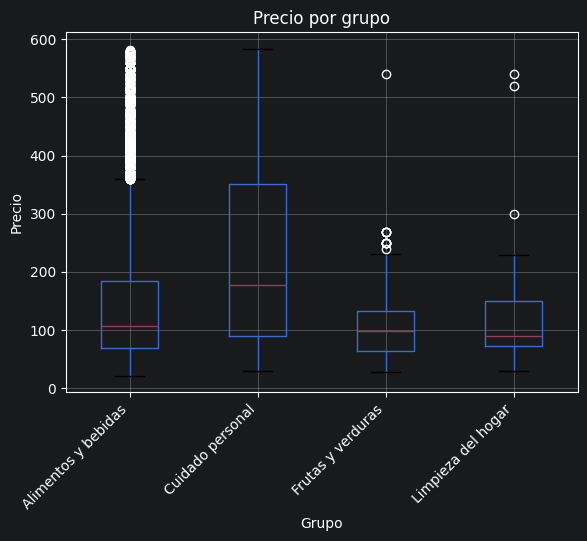

<Figure size 1200x500 with 0 Axes>

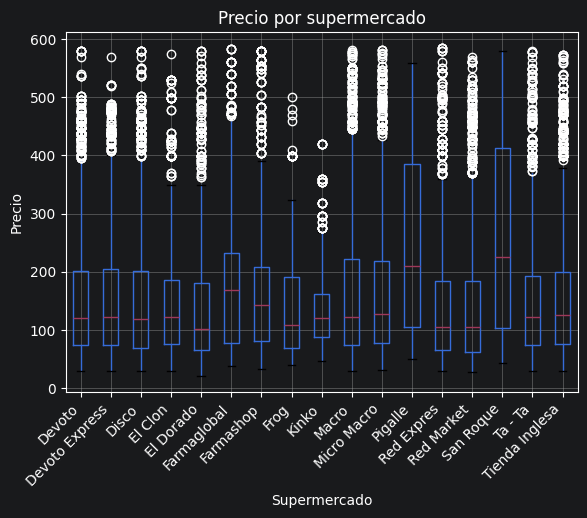

In [121]:
df.groupby("Grupo")["Precio"].describe()
df.groupby("Super")["Precio"].describe()
df.groupby("Periodo")["Precio"].describe()

# Precio promedio por grupo:
df.groupby("Grupo")["Precio"].mean().sort_values(ascending=False)

#Precio promedio por supermercado:
df.groupby("Super")["Precio"].mean().sort_values(ascending=False)

#Precio promedio por período:
df.groupby("Periodo")["Precio"].mean().sort_values(ascending=False)

# Boxplot de precio por grupo:

plt.figure(figsize=(10, 5))
df.boxplot(column="Precio", by="Grupo")
plt.title("Precio por grupo")
plt.suptitle("")
plt.xlabel("Grupo")
plt.ylabel("Precio")
plt.xticks(rotation=45, ha="right")
plt.show()

#Boxplot de precio por supermercado:

plt.figure(figsize=(12, 5))
df.boxplot(column="Precio", by="Super")
plt.title("Precio por supermercado")
plt.suptitle("")
plt.xlabel("Supermercado")
plt.ylabel("Precio")
plt.xticks(rotation=45, ha="right")
plt.show()

In [122]:
# Estadísticas de Precio por Grupo
analisis_grupo = df.groupby("Grupo")["Precio"].agg(
    cantidad="count",
    minimo="min",
    mediana="median",
    promedio="mean",
    maximo="max"
).sort_values("promedio", ascending=False)

analisis_grupo

,cantidad,minimo,mediana,promedio,maximo
Grupo,,,,,
Cuidado personal,5181,29.00,178.00,221.87,584.00
Alimentos y bebidas,12397,21.00,107.00,146.02,582.14
Limpieza del hogar,1440,30.00,89.00,109.00,540.00
Frutas y verduras,886,27.00,99.00,101.91,540.00


In [123]:
# Estadísticas de Precio por Supermercado
analisis_super = df.groupby("Super")["Precio"].agg(
    cantidad="count",
    minimo="min",
    mediana="median",
    promedio="mean",
    maximo="max"
).sort_values("promedio", ascending=False)

analisis_super

,cantidad,minimo,mediana,promedio,maximo
Super,,,,,
San Roque,295,43.00,225.00,263.96,580.00
Pigalle,233,49.00,209.00,242.58,559.00
Farmaglobal,555,37.80,167.98,196.64,582.64
Farmashop,607,33.00,142.00,185.45,579.00
Micro Macro,1312,30.17,126.87,175.15,580.89
Macro,1452,28.46,121.30,174.61,582.14
Devoto Express,1310,30.00,122.50,163.14,570.00
Devoto,1584,30.00,119.75,162.54,580.00
Disco,1620,30.00,119.00,161.84,580.00


In [ ]:
# Estadísticas de Precio por Periodo
analisis_periodo = df.groupby("Periodo")["Precio"].agg(
    cantidad="count",
    minimo="min",
    mediana="median",
    promedio="mean",
    maximo="max"
).sort_values("promedio", ascending=False)

analisis_periodo

In [124]:
# Productos con precios más altos
productos_mas_caros = df.groupby("Producto")["Precio"].agg(
    cantidad="count",
    minimo="min",
    mediana="median",
    promedio="mean",
    maximo="max"
).sort_values("maximo", ascending=False)

productos_mas_caros.head(20)

,cantidad,minimo,mediana,promedio,maximo
Producto,,,,,
"repelente spray off! family, 177 cm3",92,341.00,529.00,521.65,584.00
"repelente aerosol off! larga duración, 170 cm3",142,379.00,464.00,472.91,582.64
chorizos mezcla sueltos - centenario - extra 1 kg.,22,459.00,540.00,538.00,582.14
"afeitadora gillette mach3 dispenser x2, 2us.",69,399.00,550.20,527.93,580.89
"repelente crema off! family, 200 grs.",100,420.00,499.00,499.11,580.00
jamon cocido ottonello (1 kg.),4,580.00,580.00,580.00,580.00
"pañales huggies primeros 100 dias pequeño, 40 us.",4,571.00,580.00,577.75,580.00
perfume comun casapueblo (100 ml.),4,442.00,510.50,510.50,579.00
"perfume casapueblo 24 heures blue edt, 100 ml.",17,442.00,579.00,530.41,579.00


In [ ]:
# Productos con mayor mediana de precio
productos_mayor_mediana = df.groupby("Producto")["Precio"].agg(
    cantidad="count",
    minimo="min",
    mediana="median",
    promedio="mean",
    maximo="max"
).sort_values("mediana", ascending=False)

productos_mayor_mediana.head(20)

In [125]:
df_outliers.groupby("Grupo")["Precio"].agg(
    cantidad="count",
    minimo="min",
    mediana="median",
    promedio="mean",
    maximo="max"
).sort_values("cantidad", ascending=False)

df_outliers.groupby("Producto")["Precio"].agg(
    cantidad="count",
    minimo="min",
    mediana="median",
    promedio="mean",
    maximo="max"
).sort_values("maximo", ascending=False).head(20)

,cantidad,minimo,mediana,promedio,maximo
Producto,,,,,


<Figure size 1000x500 with 0 Axes>

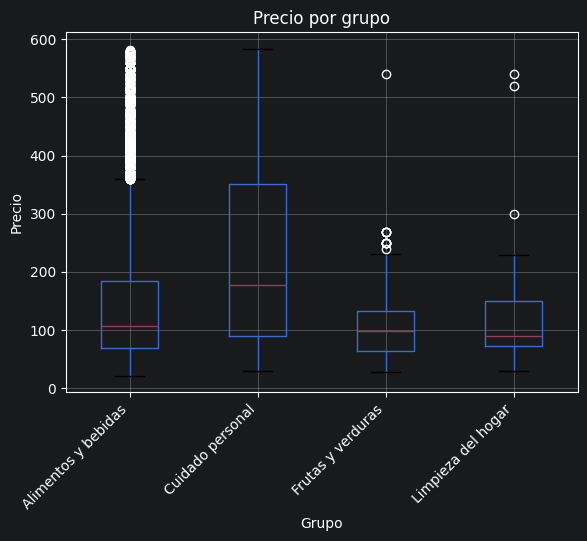

<Figure size 1200x500 with 0 Axes>

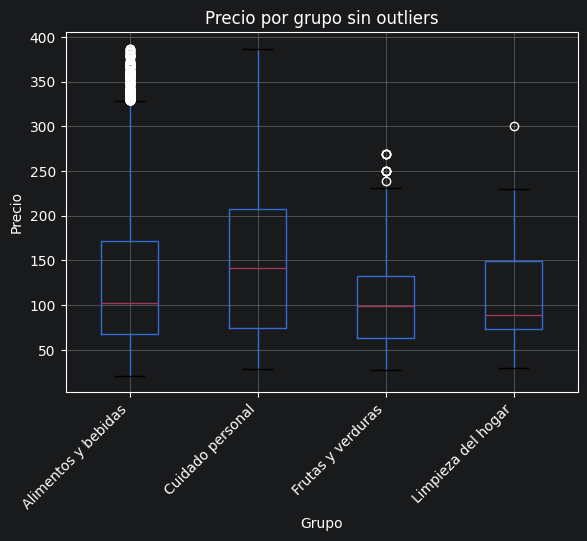

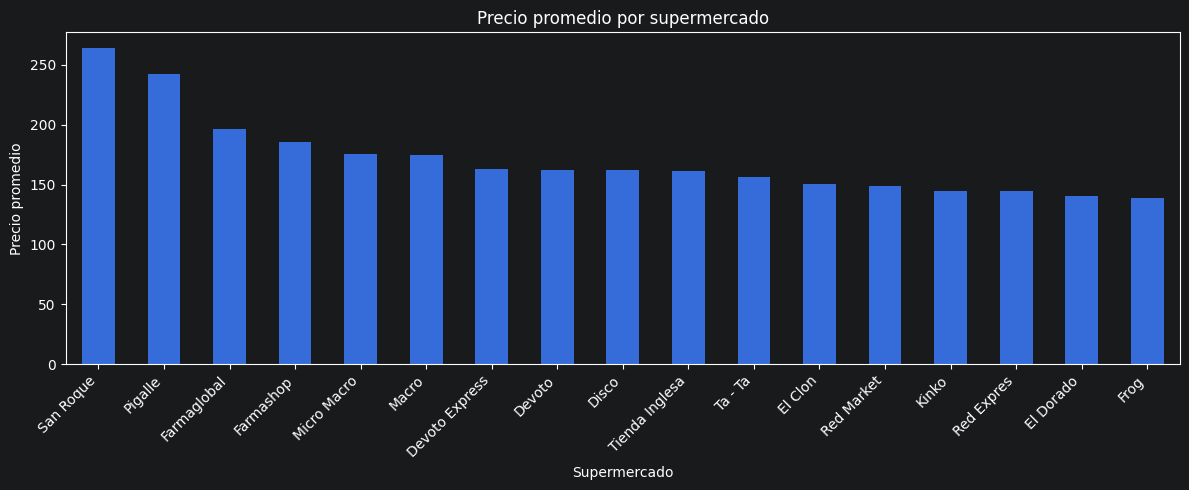

In [126]:
# Para comparar con el dataframe sin outliers:

df_sin_outliers = df[df["Precio"] <= limite_superior].copy()

df_sin_outliers.groupby("Grupo")["Precio"].agg(
    cantidad="count",
    minimo="min",
    mediana="median",
    promedio="mean",
    maximo="max"
).sort_values("promedio", ascending=False)

df_sin_outliers.groupby("Super")["Precio"].agg(
    cantidad="count",
    minimo="min",
    mediana="median",
    promedio="mean",
    maximo="max"
).sort_values("promedio", ascending=False)


plt.figure(figsize=(10, 5))
df.boxplot(column="Precio", by="Grupo")
plt.title("Precio por grupo")
plt.suptitle("")
plt.xlabel("Grupo")
plt.ylabel("Precio")
plt.xticks(rotation=45, ha="right")
plt.show()

plt.figure(figsize=(12, 5))
df_sin_outliers.boxplot(column="Precio", by="Grupo")
plt.title("Precio por grupo sin outliers")
plt.suptitle("")
plt.xlabel("Grupo")
plt.ylabel("Precio")
plt.xticks(rotation=45, ha="right")
plt.show()

precio_promedio_super = df.groupby("Super")["Precio"].mean().sort_values(ascending=False)

precio_promedio_super.plot(kind="bar", figsize=(12, 5))

plt.title("Precio promedio por supermercado")
plt.xlabel("Supermercado")
plt.ylabel("Precio promedio")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

##### Observaciones:

- Existe una relación clara entre `Grupo` y `Precio`. El grupo `Cuidado personal` presenta los precios más altos en promedio y mediana, especialmente por productos como protectores solares, pañales, cremas y tintas.
- `Alimentos y bebidas` es el grupo con mayor cantidad de registros, pero sus precios tienden a ser más bajos que los de `Cuidado personal`.
- `Limpieza del hogar` y `Frutas y verduras` presentan precios más bajos y una menor dispersión en comparación con los otros grupos.
- También se observan diferencias entre supermercados. Algunos como `San Roque`, `Pigalle`, `FarmaGlobal` y `Farmashop` muestran precios promedio más altos, lo cual puede estar relacionado con que venden más productos de cuidado personal o farmacia.
- El análisis por `Periodo` muestra que los precios promedio varían entre meses, aunque la diferencia no es tan fuerte como la observada entre grupos o supermercados.
- Los valores máximos de `Precio` afectan mucho los promedios, por lo que conviene comparar también la mediana. Esto permite reducir el efecto de los outliers.
- Al quitar outliers, las diferencias entre grupos y supermercados siguen existiendo, pero se vuelven menos extremas.
- Los productos con precios más altos pertenecen principalmente a categorías como pañales, protectores solares, tintas y cremas, por lo que no todos los outliers necesariamente son errores.

## Paso 6: Ingeniería de características

### Ingeniería de características

La **ingeniería de características** (*feature engineering*) es un proceso que implica crear nuevas variables a partir de las existentes, transformar datos o corregir formatos para mejorar el análisis y facilitar posibles modelos posteriores.

En los pasos previos ya se realizaron algunas tareas relacionadas con este proceso, como la eliminación de duplicados, el tratamiento de valores nulos, la normalización de textos y la conversión de la variable `Precio` a formato numérico.

En este dataset no existe una variable objetivo o *target* definida, por lo que la ingeniería de características se enfoca principalmente en mejorar la calidad de los datos y generar nuevas variables que permitan analizar mejor el comportamiento de los precios.

Algunas transformaciones útiles para este dataset son:

- convertir `Precio` a formato numérico,
- normalizar las variables categóricas (`Grupo`, `Producto`, `Super`),
- crear una variable de mes a partir de `Periodo`,
- crear una variable que indique si un precio es outlier,
- crear rangos de precio para clasificar productos en baratos, medios o caros,
- y calcular precios promedio por producto o supermercado.


In [ ]:

df["Precio"] = pd.to_numeric(
    df["Precio"].astype(str).str.replace(",", ".", regex=False),
    errors="coerce"
)

df["Grupo"] = df["Grupo"].str.strip().str.lower().str.capitalize()
df["Producto"] = df["Producto"].str.strip().str.lower()
df["Super"] = df["Super"].str.strip().str.title()

# Crear indicador de outlier:

Q1 = df["Precio"].quantile(0.25)
Q3 = df["Precio"].quantile(0.75)
IQR = Q3 - Q1

limite_superior = Q3 + 1.5 * IQR

df["Es_outlier_precio"] = df["Precio"] > limite_superior

# Crear rangos de precio:

df["Rango_precio"] = pd.cut(
    df["Precio"],
    bins=[0, 100, 300, 600, df["Precio"].max()],
    labels=["Bajo", "Medio", "Alto", "Muy alto"]
)

# Crear mes desde `Periodo`:

mapa_meses = {
    "Ene25": 1,
    "Feb25": 2,
    "Mar25": 3,
    "Abr25": 4,
    "May25": 5,
    "Jun25": 6,
    "Jul25": 7,
    "Ago25": 8,
    "Sep25": 9,
    "Oct25": 10,
    "Nov25": 11,
    "Dic25": 12
}

df["Mes"] = df["Periodo"].map(mapa_meses)

#### Análisis de outliers

**Intro to outliers**

Un **valor atípico** (*outlier*) es un dato que se aleja significativamente del comportamiento general del conjunto de datos.

En este dataset, el análisis de outliers se concentra principalmente en la variable `Precio`, ya que es la única variable numérica relevante. Los valores atípicos en precios pueden deberse a:

- errores de carga,
- diferencias reales entre tipos de productos,
- productos naturalmente más caros,
- promociones o precios especiales,
- o diferencias entre supermercados.

Para tratar los outliers existen varias estrategias:

- **Eliminarlos**: se eliminan las filas con precios atípicos. Esta opción puede ser útil si se confirma que son errores o si distorsionan mucho el análisis.
- **Mantenerlos**: se conservan porque pueden representar productos realmente caros o información importante.
- **Reemplazarlos**: se sustituyen por otro valor, como la mediana o un límite máximo, para reducir su efecto sin eliminar filas completas.

En este caso, antes de decidir qué hacer con los outliers, es importante analizarlos por `Grupo`, `Producto`, `Super` y `Periodo`.

**Outliers: Análisis descriptivo**

El análisis descriptivo permite caracterizar la variable `Precio` mediante medidas como la media, mediana, desviación estándar, mínimo, máximo y cuartiles.

La función `.describe()` de pandas permite obtener rápidamente estos indicadores y detectar si existen valores extremos. Si la media es mucho mayor que la mediana, esto puede indicar una distribución sesgada hacia precios altos.

In [127]:
df["Precio"].describe()

#Para ver media y mediana juntas:

print("Media:", df["Precio"].mean())
print("Mediana:", df["Precio"].median())
print("Máximo:", df["Precio"].max())

# Para calcular límites por IQR:
Q1 = df["Precio"].quantile(0.25)
Q3 = df["Precio"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

limite_inferior, limite_superior

Media: 161.12435239147908
Mediana: 119.0
Máximo: 584.0


(np.float64(-116.0), np.float64(388.0))

In [128]:
# Para guardar los outliers:
df_outliers = df[
    (df["Precio"] < limite_inferior) |
    (df["Precio"] > limite_superior)
].copy()

df_outliers

#Como el precio no debería ser negativo, me enfoco en los superiores:
df_outliers = df[df["Precio"] > limite_superior].copy()

df_outliers.sort_values("Precio", ascending=False).head(20)

#Para resumirlos:
df_outliers.groupby("Grupo")["Precio"].agg(
    cantidad="count",
    minimo="min",
    mediana="median",
    promedio="mean",
    maximo="max"
).sort_values("cantidad", ascending=False)

df_outliers.groupby("Producto")["Precio"].agg(
    cantidad="count",
    minimo="min",
    mediana="median",
    promedio="mean",
    maximo="max"
).sort_values("maximo", ascending=False).head(20)

,cantidad,minimo,mediana,promedio,maximo
Producto,,,,,
"repelente spray off! family, 177 cm3",90,456.85,529.00,525.67,584.00
"repelente aerosol off! larga duración, 170 cm3",140,399.00,466.50,474.25,582.64
chorizos mezcla sueltos - centenario - extra 1 kg.,22,459.00,540.00,538.00,582.14
"afeitadora gillette mach3 dispenser x2, 2us.",69,399.00,550.20,527.93,580.89
jamon cocido ottonello (1 kg.),4,580.00,580.00,580.00,580.00
"pañales huggies primeros 100 dias pequeño, 40 us.",4,571.00,580.00,577.75,580.00
"repelente crema off! family, 200 grs.",100,420.00,499.00,499.11,580.00
perfume comun casapueblo (100 ml.),4,442.00,510.50,510.50,579.00
"perfume casapueblo 24 heures blue edt, 100 ml.",17,442.00,579.00,530.41,579.00


In [130]:
df.sort_values("Precio", ascending=False).head(10)

,Periodo,Grupo,Producto,Super,Precio
16214,Nov25,Cuidado personal,"repelente spray off! family, 177 cm3",Red Expres,584.00
19546,Sep25,Cuidado personal,"repelente spray off! family, 177 cm3",Red Expres,584.00
17887,Oct25,Cuidado personal,"repelente spray off! family, 177 cm3",Red Expres,584.00
4775,Dic25,Cuidado personal,"repelente spray off! family, 177 cm3",Red Expres,584.00
16174,Nov25,Cuidado personal,"repelente aerosol off! larga duración, 170 cm3",Farmaglobal,582.64
19508,Sep25,Cuidado personal,"repelente aerosol off! larga duración, 170 cm3",Farmaglobal,582.64
17848,Oct25,Cuidado personal,"repelente aerosol off! larga duración, 170 cm3",Farmaglobal,582.64
4734,Dic25,Cuidado personal,"repelente aerosol off! larga duración, 170 cm3",Farmaglobal,582.64
7101,Feb25,Alimentos y bebidas,chorizos mezcla sueltos - centenario - extra 1...,Macro,582.14
7817,Feb25,Cuidado personal,"afeitadora gillette mach3 dispenser x2, 2us.",Micro Macro,580.89


In [129]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Precio,"19,904.00",161.12,124.00,21.00,73.00,119.00,199.00,584.00


Si bien la experiencia es un componente importante en el análisis de los resultados de la tabla anterior, podemos utilizar ciertas reglas para detectar valores atípicos, como observar el valor mínimo y máximo de una variable y compararlo con sus percentiles 25%, 50% y 75%.

> Observaciones
>
> La columna `Precio` tiene una media aproximada de **238,65**, una mediana o percentil 50% de **129**, y un valor máximo de **25.800**.
>
> Esta diferencia indica que existen precios muy altos en comparación con la mayoría de los registros. Como la media es bastante mayor que la mediana, la distribución está sesgada hacia la derecha.
>
> El valor máximo de **25.800** podría parecer un valor atípico o incluso un posible error de carga. Sin embargo, también podría corresponder a un producto efectivamente caro, suena a que es muy caro para que lo sea, pero debemos de investigar.
>
> Por este motivo, antes de eliminarlo, decidimos analizar a qué `Producto`, `Grupo`, `Super` y `Periodo` pertenece ese registro.


**Outliers: Visualización**

Dibujar un diagrama de caja de la variable `Precio` permite identificar visualmente los valores atípicos. En este tipo de gráfico, los puntos que quedan alejados del cuerpo principal de la caja representan precios que se salen del rango esperado según la distribución de los datos.

En este dataset, el boxplot es especialmente útil porque `Precio` presenta valores muy altos en comparación con la mayoría de los registros. Estos valores pueden corresponder a errores de carga o a productos naturalmente más caros.


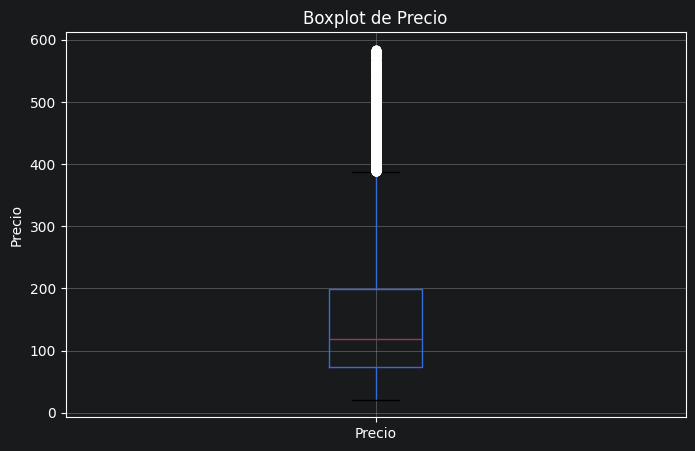

<Figure size 1000x500 with 0 Axes>

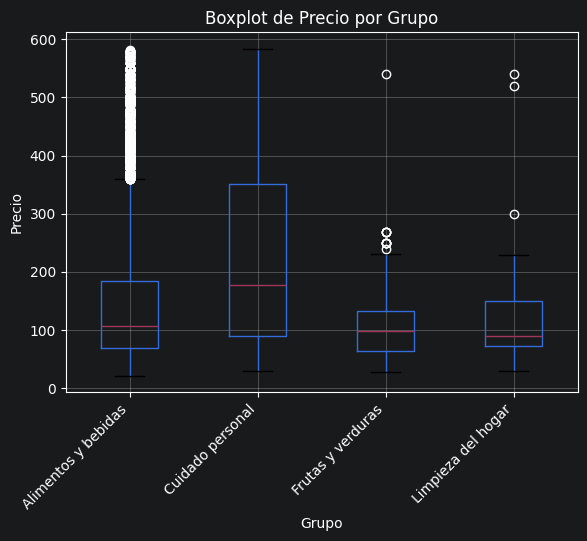

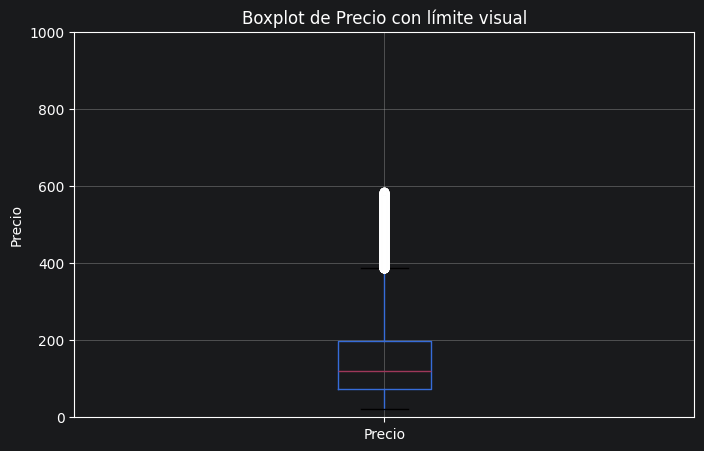

In [131]:
plt.figure(figsize=(8, 5))
df.boxplot(column="Precio")

plt.title("Boxplot de Precio")
plt.ylabel("Precio")
plt.show()


#Para verlo por grupo:

plt.figure(figsize=(10, 5))
df.boxplot(column="Precio", by="Grupo")

plt.title("Boxplot de Precio por Grupo")
plt.suptitle("")
plt.xlabel("Grupo")
plt.ylabel("Precio")
plt.xticks(rotation=45, ha="right")
plt.show()


# visualización más clara sin que los extremos aplasten el gráfico:

plt.figure(figsize=(8, 5))
df.boxplot(column="Precio")
plt.ylim(0, 1000)

plt.title("Boxplot de Precio con límite visual")
plt.ylabel("Precio")
plt.show()

#### Observaciones
>
> En este dataset, la variable afectada por outliers es `Precio`, ya que es la única variable numérica relevante.
>
> A partir del boxplot y del análisis descriptivo, se observa que existen precios muy superiores al comportamiento general de la mayoría de los datos. Por ejemplo, mientras la mediana de `Precio` es cercana a **129**, el valor máximo llega a **25.800**.
>
> Esto indica que algunos registros se alejan mucho del rango típico de precios. Sin embargo, no necesariamente todos son errores: algunos pueden corresponder a productos naturalmente caros, como protectores solares, pañales, tintas o cremas.
>
> Para decidir si un precio debe considerarse outlier, se pueden establecer límites inferior y superior utilizando el rango intercuartílico (`IQR`).

## Exporto dataframe a un excel final, ya procesado

In [97]:

# Crear carpeta si no existe
processed_path = Path('../data/processed')
processed_path.mkdir(parents=True, exist_ok=True)

# Guardar como Excel
df.to_excel(processed_path / 'cadenas_unificadas_2025_procesado.xlsx', index=False)